In [5]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

torch.manual_seed(42)
np.random.seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

Device: cuda


In [6]:
# Chuẩn hóa MNIST với mean/std của tập train.
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,)),
])
train_dataset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=64, shuffle=False)

print(f'Số ảnh train: {len(train_dataset)}, test: {len(test_dataset)}')

100%|██████████| 9.91M/9.91M [00:00<00:00, 19.2MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 510kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.70MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 12.5MB/s]

Số ảnh train: 60000, test: 10000


In [7]:
import torch.nn as nn

class MNIST_CNN(nn.Module):
  def __init__(self):
    super().__init__()
    self.conv1 = nn.Conv2d(1, 16, kernel_size=3, stride=1, padding=0)   # 28->26
    self.conv2 = nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=0)  # 13->11
    self.pool  = nn.MaxPool2d(kernel_size=2, stride=2)
    self.fc1   = nn.Linear(32 * 5 * 5, 10)

  def forward(self, x):
    x = self.pool(torch.relu(self.conv1(x)))   # -> (16, 13, 13)
    x = self.pool(torch.relu(self.conv2(x)))   # -> (32,  5,  5)
    x = x.view(x.size(0), -1)                  # flatten
    x = self.fc1(x)                            # logits
    return x

model = MNIST_CNN().to(device)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(model)
print(f'Tổng tham số: {n_params:,}')

# So sánh nhanh với ANN(784->128->10) ở bài trước: ~101 nghìn params và ~97% acc.
# CNN này thường ít tham số hơn (~13 nghìn) mà acc cao hơn.
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)

MNIST_CNN(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=800, out_features=10, bias=True)
)
Tổng tham số: 12,810


Epoch 1/5  train_loss=0.0399  train_acc=98.78%  test_loss=0.0409  test_acc=98.68%
Epoch 2/5  train_loss=0.0352  train_acc=98.94%  test_loss=0.0381  test_acc=98.82%
Epoch 3/5  train_loss=0.0307  train_acc=99.08%  test_loss=0.0323  test_acc=98.97%
Epoch 4/5  train_loss=0.0271  train_acc=99.16%  test_loss=0.0332  test_acc=98.92%
Epoch 5/5  train_loss=0.0246  train_acc=99.19%  test_loss=0.0358  test_acc=98.84%


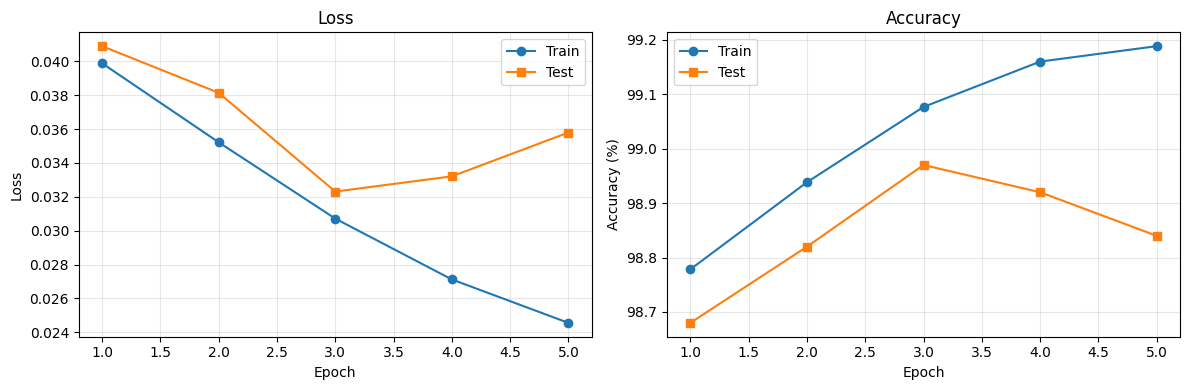

In [10]:
def evaluate(model, loader):
    model.eval()
    loss_sum, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss_sum += criterion(outputs, labels).item() * images.size(0)
            correct  += (outputs.argmax(1) == labels).sum().item()
            total    += labels.size(0)
    return loss_sum / total, correct / total

num_epochs = 5
loss_history, acc_history = [], []
test_loss_history, test_acc_history = [], []

for epoch in range(num_epochs):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0) # Corrected indentation
        correct      += (outputs.argmax(1) == labels).sum().item()
        total        += labels.size(0)

    train_loss = running_loss / total
    train_acc  = correct / total
    test_loss, test_acc = evaluate(model, test_loader)
    loss_history.append(train_loss); acc_history.append(train_acc)
    test_loss_history.append(test_loss); test_acc_history.append(test_acc)

    print(f'Epoch {epoch+1}/{num_epochs}  '
          f'train_loss={train_loss:.4f}  train_acc={train_acc*100:.2f}%  '
          f'test_loss={test_loss:.4f}  test_acc={test_acc*100:.2f}%')
epochs = range(1, num_epochs + 1) # Corrected indentation, outside epoch loop as it's for plotting after training
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(epochs, loss_history,      'o-', label='Train')
axes[0].plot(epochs, test_loss_history, 's-', label='Test')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss'); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[0].set_title('Loss')
axes[1].plot(epochs, [a*100 for a in acc_history],      'o-', label='Train')
axes[1].plot(epochs, [a*100 for a in test_acc_history], 's-', label='Test')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy (%)'); axes[1].legend(); axes[1].grid(alpha=0.3)
axes[1].set_title('Accuracy')
plt.tight_layout(); plt.show()

In [11]:
test_loss, test_acc = evaluate(model, test_loader)
print(f'Final test accuracy: {test_acc*100:.2f}%')
print(f'(MNIST-ANN ở bài trước đạt ~97-98%; CNN nhỏ này thường đạt 98.5-99%.)')

Final test accuracy: 98.84%
(MNIST-ANN ở bài trước đạt ~97-98%; CNN nhỏ này thường đạt 98.5-99%.)


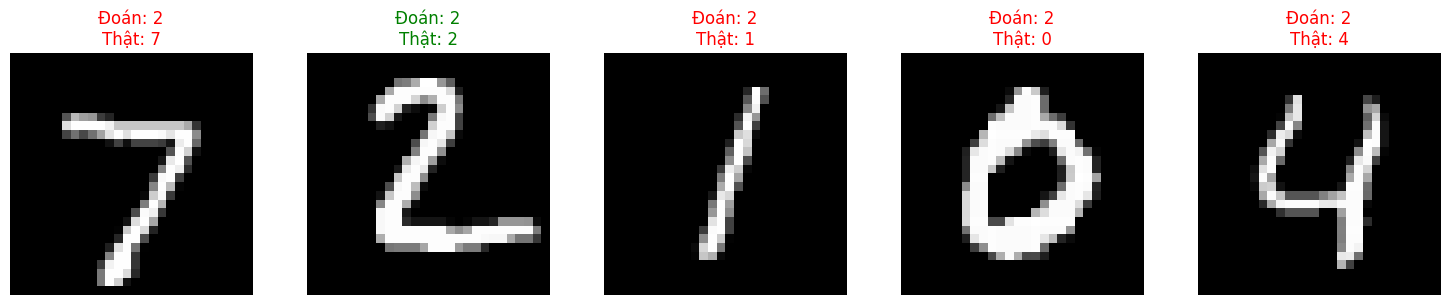

In [28]:
model.eval()
images, labels = next(iter(test_loader))
images, labels = images.to(device), labels.to(device)
with torch.no_grad():
    preds = model(images).argmax(1)

fig, axes = plt.subplots(1, 5, figsize=(15, 3))
for i in range(5):
    img = images[i].cpu().squeeze() * 0.3081 + 0.1307   # un-normalize để nhìn cho đẹp
    axes[i].imshow(img, cmap='gray')
    color = 'green' if preds[i] == labels[i] else 'red'
    axes[i].set_title(f'Đoán: {preds[i].item()}\nThật: {labels[i].item()}', color=color)
    axes[i].axis('off')
plt.tight_layout(); plt.show()

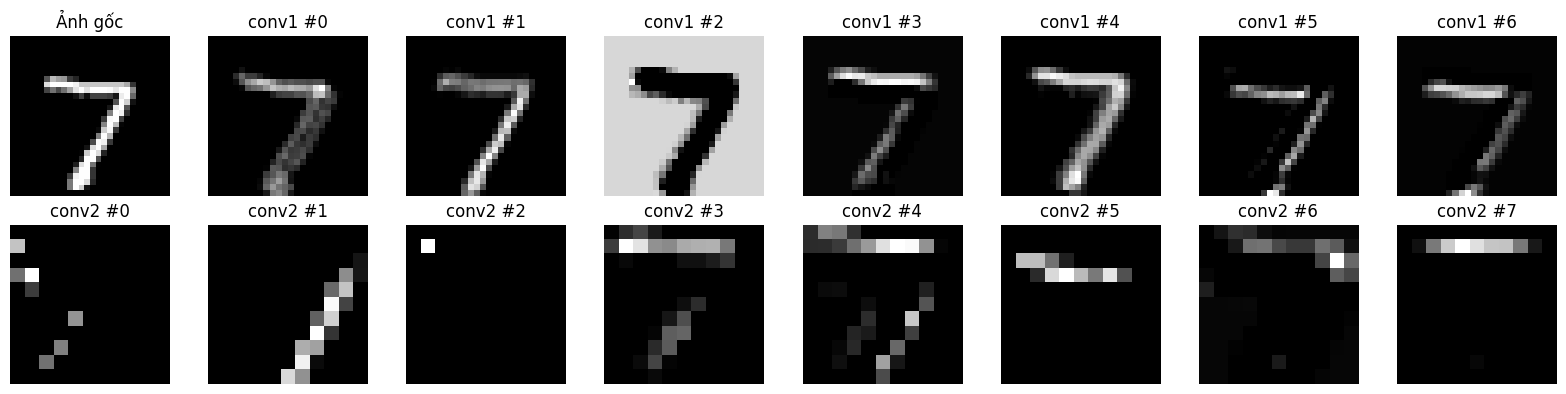

Quan sát: filter conv1 thường nhận các cạnh hoặc đường nét đơn giản.
         filter conv2 nhận các đặc trưng phức tạp hơn (mảng, hình.)


In [17]:
model.eval()
images, _ = next(iter(test_loader))
img = images[0].unsqueeze(0).to(device)

with torch.no_grad():
    fmap1 = torch.relu(model.conv1(img))           # (1, 16, 26, 26)
    fmap2 = torch.relu(model.conv2(model.pool(fmap1)))  # (1, 32, 11, 11)

fig, axes = plt.subplots(2, 8, figsize=(16, 4))
axes[0, 0].imshow(img.cpu().squeeze() * 0.3081 + 0.1307, cmap='gray')
axes[0, 0].set_title('Ảnh gốc'); axes[0, 0].axis('off')
for i in range(7):
    axes[0, i+1].imshow(fmap1[0, i].cpu(), cmap='gray')
    axes[0, i+1].set_title(f'conv1 #{i}'); axes[0, i+1].axis('off')
for i in range(8):
    axes[1, i].imshow(fmap2[0, i].cpu(), cmap='gray')
    axes[1, i].set_title(f'conv2 #{i}'); axes[1, i].axis('off')
plt.tight_layout(); plt.show()

print('Quan sát: filter conv1 thường nhận các cạnh hoặc đường nét đơn giản.')
print('         filter conv2 nhận các đặc trưng phức tạp hơn (mảng, hình.)')

BÀI TẬP VỀ NHÀ:

Epoch 1/10  train_loss=0.0222  train_acc=99.28%  test_loss=0.0354  test_acc=98.82%
Epoch 2/10  train_loss=0.0199  train_acc=99.37%  test_loss=0.0322  test_acc=98.94%
Epoch 3/10  train_loss=0.0172  train_acc=99.44%  test_loss=0.0352  test_acc=98.95%
Epoch 4/10  train_loss=0.0153  train_acc=99.49%  test_loss=0.0325  test_acc=99.09%
Epoch 5/10  train_loss=0.0148  train_acc=99.54%  test_loss=0.0329  test_acc=98.97%
Epoch 6/10  train_loss=0.0136  train_acc=99.58%  test_loss=0.0374  test_acc=98.92%
Epoch 7/10  train_loss=0.0115  train_acc=99.63%  test_loss=0.0363  test_acc=98.91%
Epoch 8/10  train_loss=0.0108  train_acc=99.67%  test_loss=0.0328  test_acc=99.03%
Epoch 9/10  train_loss=0.0100  train_acc=99.67%  test_loss=0.0387  test_acc=98.90%
Epoch 10/10  train_loss=0.0097  train_acc=99.70%  test_loss=0.0416  test_acc=98.81%


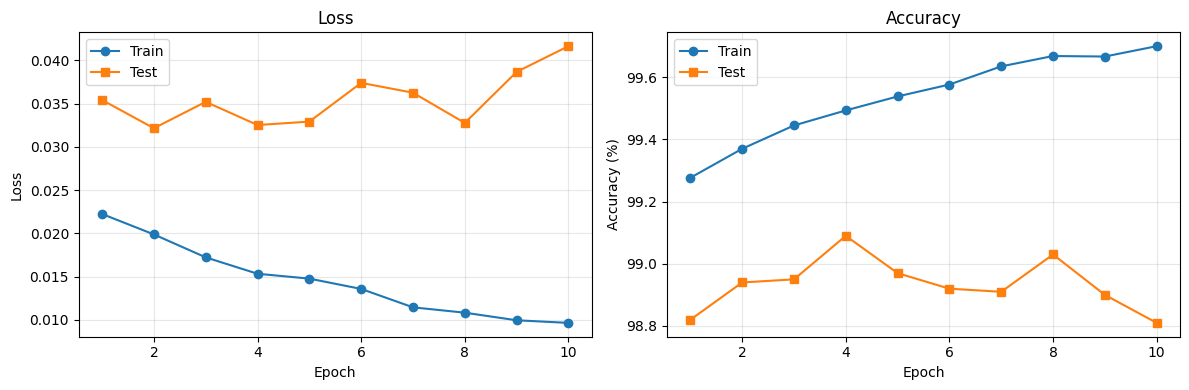

Test Acc Epoch 5 : 98.97
Test Acc Epoch 10: 98.81
Chênh lệch: -0.16000000000000458


In [18]:
#Bài 1: Train lâu hơn

def evaluate(model, loader):
    model.eval()
    loss_sum, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss_sum += criterion(outputs, labels).item() * images.size(0)
            correct  += (outputs.argmax(1) == labels).sum().item()
            total    += labels.size(0)
    return loss_sum / total, correct / total

num_epochs = 10
loss_history, acc_history = [], []
test_loss_history, test_acc_history = [], []

for epoch in range(num_epochs):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        correct      += (outputs.argmax(1) == labels).sum().item()
        total        += labels.size(0)

    train_loss = running_loss / total
    train_acc  = correct / total
    test_loss, test_acc = evaluate(model, test_loader)
    loss_history.append(train_loss); acc_history.append(train_acc)
    test_loss_history.append(test_loss); test_acc_history.append(test_acc)

    print(f'Epoch {epoch+1}/{num_epochs}  '
          f'train_loss={train_loss:.4f}  train_acc={train_acc*100:.2f}%  '
          f'test_loss={test_loss:.4f}  test_acc={test_acc*100:.2f}%')


epochs = range(1, num_epochs + 1)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(epochs, loss_history,      'o-', label='Train')
axes[0].plot(epochs, test_loss_history, 's-', label='Test')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss'); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[0].set_title('Loss')
axes[1].plot(epochs, [a*100 for a in acc_history],      'o-', label='Train')
axes[1].plot(epochs, [a*100 for a in test_acc_history], 's-', label='Test')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy (%)'); axes[1].legend(); axes[1].grid(alpha=0.3)
axes[1].set_title('Accuracy')
plt.tight_layout(); plt.show()
print("Test Acc Epoch 5 :", test_acc_history[4] * 100)
print("Test Acc Epoch 10:", test_acc_history[9] * 100)

diff = (test_acc_history[9] - test_acc_history[4]) * 100
print("Chênh lệch:", diff)

In [19]:
#Bài 2: Thêm tầng tích chập thứ ba
class MNIST_CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3)   # 28→26
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3)  # 13→11
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.pool  = nn.MaxPool2d(kernel_size=2, stride=2)
        self.fc1   = nn.Linear(64 * 2 * 2, 10)

    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))   # → (16, 13, 13)
        x = self.pool(torch.relu(self.conv2(x)))   # → (32,  5,  5)
        x = self.pool(torch.relu(self.conv3(x)))
        x = x.view(x.size(0), -1)                  # flatten
        x = self.fc1(x)                            # logits
        return x

model = MNIST_CNN().to(device)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(model)
print(f'Tổng tham số: {n_params:,}')

# So sánh nhanh với ANN(784→128→10) ở bài trước: ~101 nghìn params và ~97% acc.
# CNN này thường ít tham số hơn (~13 nghìn) mà acc cao hơn.


criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)

MNIST_CNN(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1))
  (conv3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=256, out_features=10, bias=True)
)
Tổng tham số: 25,866


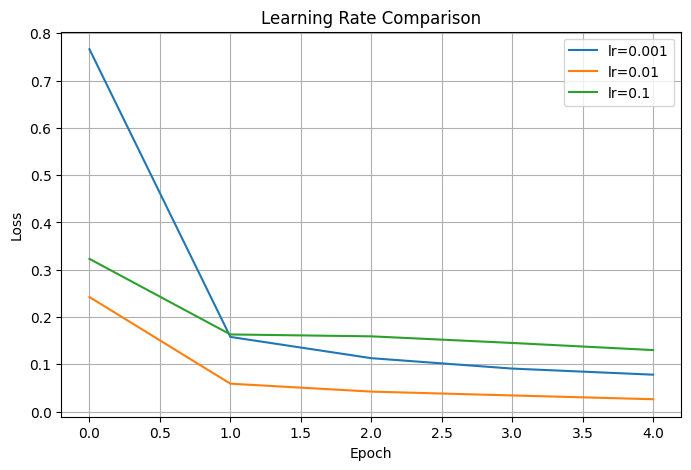

In [22]:
#Bài 3: Thay đổi learning rate
def train_with_lr(lr):

    model = MNIST_CNN().to(device)

    criterion = nn.CrossEntropyLoss()

    optimizer = optim.SGD(
        model.parameters(),
        lr=lr,
        momentum=0.9
    )

    losses = []

    for epoch in range(5):

        model.train()

        running_loss = 0

        for images, labels in train_loader:

            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)

            loss = criterion(outputs, labels)

            loss.backward()

            optimizer.step()

            running_loss += loss.item()

        losses.append(
            running_loss / len(train_loader)
        )

    return losses
loss_0001 = train_with_lr(0.001)
loss_001  = train_with_lr(0.01)
loss_01   = train_with_lr(0.1)
plt.figure(figsize=(8,5))

plt.plot(loss_0001, label='lr=0.001')
plt.plot(loss_001, label='lr=0.01')
plt.plot(loss_01, label='lr=0.1')

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Learning Rate Comparison")

plt.legend()
plt.grid(True)

plt.show()

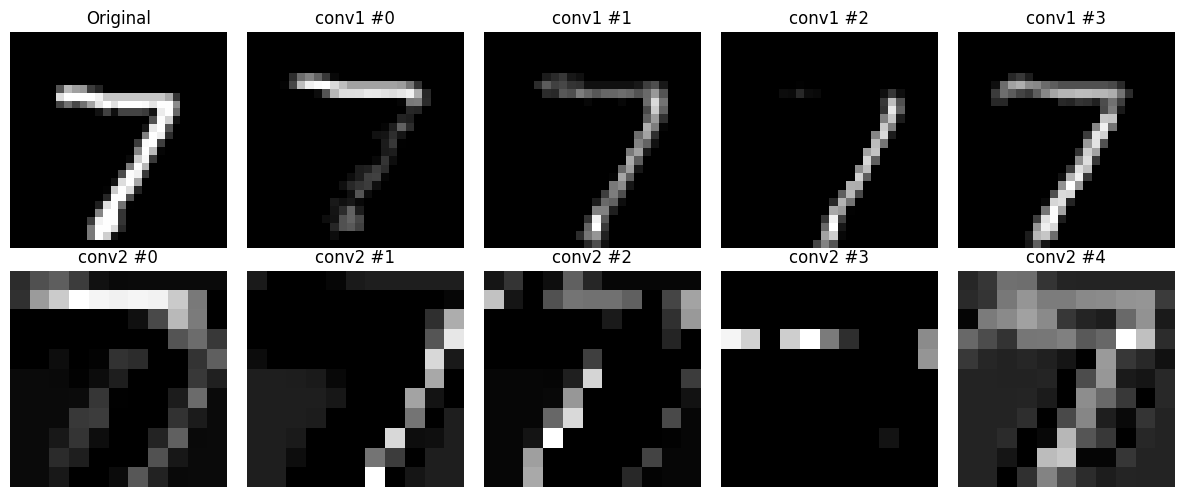

In [23]:
#Bài 4: Vẽ thêm feature maps từ conv2
model.eval()

images, _ = next(iter(test_loader))

img = images[0].unsqueeze(0).to(device)

with torch.no_grad():

    h1 = torch.relu(
        model.conv1(img)
    )

    h1_pool = model.pool(h1)

    h2 = torch.relu(
        model.conv2(h1_pool)
    )

fig, axes = plt.subplots(
    2,
    5,
    figsize=(12,5)
)

axes[0,0].imshow(
    img.cpu().squeeze() * 0.3081 + 0.1307,
    cmap='gray'
)

axes[0,0].set_title('Original')
axes[0,0].axis('off')

for i in range(4):

    axes[0,i+1].imshow(
        h1[0,i].cpu(),
        cmap='gray'
    )

    axes[0,i+1].set_title(
        f'conv1 #{i}'
    )

    axes[0,i+1].axis('off')

for i in range(5):

    axes[1,i].imshow(
        h2[0,i].cpu(),
        cmap='gray'
    )

    axes[1,i].set_title(
        f'conv2 #{i}'
    )

    axes[1,i].axis('off')

plt.tight_layout()
plt.show()

Device: cuda
Train: 60000
Test : 10000
MNIST_CNN(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout): Dropout(p=0.25, inplace=False)
  (fc1): Linear(in_features=800, out_features=10, bias=True)
)
Epoch 1/10 | Train Acc: 86.23% | Test Acc: 97.62%
Epoch 2/10 | Train Acc: 93.99% | Test Acc: 98.30%
Epoch 3/10 | Train Acc: 95.06% | Test Acc: 98.73%
Epoch 4/10 | Train Acc: 95.62% | Test Acc: 98.89%
Epoch 5/10 | Train Acc: 95.96% | Test Acc: 98.62%
Epoch 6/10 | Train Acc: 96.22% | Test Acc: 98.93%
Epoch 7/10 | Train Acc: 96.50% | Test Acc: 98.94%
Epoch 8/10 | Train Acc: 96.69% | Test Acc: 98.89%
Epoch 9/10 | Train Acc: 96.64% | Test Acc: 99.04%
Epoch 10/10 | Train Acc: 96.81% | Test Acc: 99.02%


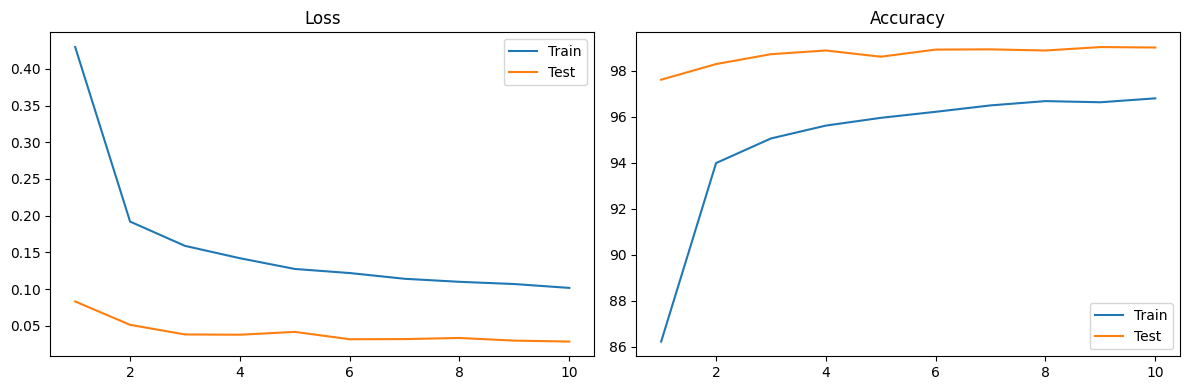

Final Test Accuracy: 99.02%


In [31]:
#Bài 5: Thêm Dropout và Data Augmentation
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

torch.manual_seed(42)
np.random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Device:", device)
train_transform = transforms.Compose([
    transforms.RandomAffine(
        degrees=10,
        translate=(0.1, 0.1)
    ),
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])
train_dataset = torchvision.datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=train_transform
)

test_dataset = torchvision.datasets.MNIST(
    root='./data',
    train=False,
    download=True,
    transform=test_transform
)

train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False
)

print(f"Train: {len(train_dataset)}")
print(f"Test : {len(test_dataset)}")
class MNIST_CNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(
            1, 16,
            kernel_size=3
        )

        self.conv2 = nn.Conv2d(
            16, 32,
            kernel_size=3
        )

        self.pool = nn.MaxPool2d(
            kernel_size=2,
            stride=2
        )

        self.dropout = nn.Dropout(
            p=0.25
        )

        self.fc1 = nn.Linear(
            32 * 5 * 5,
            10
        )

    def forward(self, x):

        x = self.pool(
            torch.relu(
                self.conv1(x)
            )
        )

        x = self.pool(
            torch.relu(
                self.conv2(x)
            )
        )

        x = self.dropout(x)

        x = x.view(
            x.size(0),
            -1
        )

        x = self.fc1(x)

        return x
model = MNIST_CNN().to(device)

criterion = nn.CrossEntropyLoss()

optimizer = optim.SGD(
    model.parameters(),
    lr=0.01,
    momentum=0.9
)

print(model)
def evaluate(model, loader):

    model.eval()

    loss_sum = 0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(
                outputs,
                labels
            )

            loss_sum += (
                loss.item() *
                images.size(0)
            )

            correct += (
                outputs.argmax(1) == labels
            ).sum().item()

            total += labels.size(0)

    return (
        loss_sum / total,
        correct / total
    )
num_epochs = 10

loss_history = []
acc_history = []

test_loss_history = []
test_acc_history = []

for epoch in range(num_epochs):

    model.train()

    running_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(
            outputs,
            labels
        )

        loss.backward()

        optimizer.step()

        running_loss += (
            loss.item() *
            images.size(0)
        )

        correct += (
            outputs.argmax(1) == labels
        ).sum().item()

        total += labels.size(0)

    train_loss = running_loss / total
    train_acc = correct / total

    test_loss, test_acc = evaluate(
        model,
        test_loader
    )

    loss_history.append(train_loss)
    acc_history.append(train_acc)

    test_loss_history.append(test_loss)
    test_acc_history.append(test_acc)

    print(
        f"Epoch {epoch+1}/{num_epochs} | "
        f"Train Acc: {train_acc*100:.2f}% | "
        f"Test Acc: {test_acc*100:.2f}%"
    )
epochs = range(
    1,
    num_epochs + 1
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(12,4)
)

axes[0].plot(
    epochs,
    loss_history,
    label="Train"
)

axes[0].plot(
    epochs,
    test_loss_history,
    label="Test"
)

axes[0].set_title("Loss")
axes[0].legend()

axes[1].plot(
    epochs,
    [x*100 for x in acc_history],
    label="Train"
)

axes[1].plot(
    epochs,
    [x*100 for x in test_acc_history],
    label="Test"
)

axes[1].set_title("Accuracy")
axes[1].legend()

plt.tight_layout()
plt.show()
test_loss, test_acc = evaluate(
    model,
    test_loader
)

print(
    f"Final Test Accuracy: {test_acc*100:.2f}%"
)